In [1]:
# Versão da Linguagem Python
from platform import python_version
print('Versão da Linguagem Python Usada Neste Jupyter Notebook:', python_version())

Versão da Linguagem Python Usada Neste Jupyter Notebook: 3.12.13


In [2]:
# Importanto Bibliotecas

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pmdarima as pm
import requests
import sklearn
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, make_scorer, mean_squared_error, explained_variance_score
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import root_mean_squared_error
from plotly.subplots import make_subplots
import plotly.graph_objects as go

In [3]:
# Versões dos pacotes usados neste jupyter notebook
%reload_ext watermark
%watermark -a "Flavio Renan Sant Anna" --iversions

Author: Flavio Renan Sant Anna

matplotlib: 3.10.9
numpy     : 2.2.6
pandas    : 3.0.2
platform  : 1.0.8
plotly    : 6.7.0
pmdarima  : 2.1.1
requests  : 2.33.1
seaborn   : 0.13.2
sklearn   : 1.8.0
tensorflow: 2.21.0
yfinance  : 1.3.0



In [4]:
# Definimos Todas Variáveis
tickers = {
    'Bovespa': '^BVSP',        
    'Dolar': 'BRL=X',        
    'SP500': '^GSPC',        
    'Shanghai': '000001.SS', # Bolsa da China
    'Petroleo': 'BZ=F',      
    'Minerio': 'TIO=F',      
    'Ouro': 'GC=F',
    'Juros_BR': 'LFTS11.SA',
    'Inflacao_BR': 'IMAB11.SA'
}

print("Baixando as variaveis ...")

Baixando as variaveis ...


In [5]:
#  Baixamos os dados
df = yf.download(list(tickers.values()), period='3y')['Close']
df.rename(columns={v: k for k, v in tickers.items()}, inplace=True)

[*********************100%***********************]  9 of 9 completed


In [6]:
# Tratamento de valores nulos devido a calendários de feriados diferentes
df.ffill(inplace=True)
df.dropna(inplace=True)

In [7]:
df.shape

(782, 9)

In [8]:
df.head()

Ticker,Shanghai,Dolar,Petroleo,Ouro,Inflacao_BR,Juros_BR,Minerio,Bovespa,SP500
Date,,,,,,,,,
2023-08-28,3098.639893,4.8704,84.419998,1917.900024,79.5,110.549500,108.309998,117121.0,4433.310059
2023-08-29,3135.889893,4.8726,85.489998,1936.500000,79.5,110.609734,108.650002,118404.0,4497.629883
2023-08-30,3137.139893,4.8513,85.860001,1944.300049,79.5,110.681862,108.989998,117535.0,4514.870117
2023-08-31,3119.879883,4.8884,86.860001,1938.199951,79.5,110.745728,109.400002,115742.0,4507.660156
2023-09-01,3133.250000,4.9538,88.550003,1939.800049,79.5,110.801537,118.190002,117893.0,4515.770020


In [9]:
df.columns

Index(['Shanghai', 'Dolar', 'Petroleo', 'Ouro', 'Inflacao_BR', 'Juros_BR',
       'Minerio', 'Bovespa', 'SP500'],
      dtype='str', name='Ticker')

In [10]:
# Proporção de dados para treino e teste
train_size = int(len(df) * 0.8)
test_size = len(df) - train_size

In [11]:
# Define o tamanho das amostras
train, test = df.iloc[0:train_size], df.iloc[train_size:len(df)]

In [12]:
print('Tamanho da Amostra de Treino:', len(train))
print('Tamanho da Amostra de Teste:', len(test))

Tamanho da Amostra de Treino: 625
Tamanho da Amostra de Teste: 157


In [13]:
print(train.shape)
train.head()

(625, 9)


Ticker,Shanghai,Dolar,Petroleo,Ouro,Inflacao_BR,Juros_BR,Minerio,Bovespa,SP500
Date,,,,,,,,,
2023-08-28,3098.639893,4.8704,84.419998,1917.900024,79.5,110.549500,108.309998,117121.0,4433.310059
2023-08-29,3135.889893,4.8726,85.489998,1936.500000,79.5,110.609734,108.650002,118404.0,4497.629883
2023-08-30,3137.139893,4.8513,85.860001,1944.300049,79.5,110.681862,108.989998,117535.0,4514.870117
2023-08-31,3119.879883,4.8884,86.860001,1938.199951,79.5,110.745728,109.400002,115742.0,4507.660156
2023-09-01,3133.250000,4.9538,88.550003,1939.800049,79.5,110.801537,118.190002,117893.0,4515.770020


In [14]:
# Variáveis preditoras
variaveis_preditoras = ['Dolar', 
                        'Petroleo',                          
                        'SP500',                                                 
                        'Minerio',
                        'Shanghai',
                        'Ouro',
                        'Juros_BR',
                        'Inflacao_BR'
                       ]                         

In [15]:
# Prepara o padronizador das variáveis preditoras
scaler_preditores = MinMaxScaler()

In [16]:
# Fit nos dados de treino
scaler_preditores = scaler_preditores.fit(train[variaveis_preditoras].to_numpy())

In [17]:
# Transform nos dados de treino
train[variaveis_preditoras] = scaler_preditores.transform(train[variaveis_preditoras].to_numpy())

In [18]:
train.head()

Ticker,Shanghai,Dolar,Petroleo,Ouro,Inflacao_BR,Juros_BR,Minerio,Bovespa,SP500
Date,,,,,,,,,
2023-08-28,0.270969,0.038278,0.677651,0.034421,0.0,0.000000,0.322050,117121.0,0.110472
2023-08-29,0.296428,0.039758,0.706085,0.040741,0.0,0.001674,0.328480,118404.0,0.132963
2023-08-30,0.297283,0.025429,0.715918,0.043391,0.0,0.003678,0.334909,117535.0,0.138991
2023-08-31,0.285486,0.050387,0.742493,0.041318,0.0,0.005452,0.342663,115742.0,0.136470
2023-09-01,0.294624,0.094383,0.787404,0.041862,0.0,0.007003,0.508888,117893.0,0.139306


In [19]:
# Transform nos dados de teste
test[variaveis_preditoras] = scaler_preditores.transform(test[variaveis_preditoras].to_numpy())

In [20]:
test.head()

Ticker,Shanghai,Dolar,Petroleo,Ouro,Inflacao_BR,Juros_BR,Minerio,Bovespa,SP500
Date,,,,,,,,,
2026-01-21,0.966956,0.377262,0.167951,1.024533,0.986087,1.002779,0.287065,171817.0,0.964457
2026-01-22,0.970808,0.339926,0.136593,1.050696,0.986087,1.005002,0.286309,175589.0,0.977650
2026-01-23,0.980095,0.316313,0.184959,1.073598,1.011826,1.008336,0.285174,178859.0,0.978440
2026-01-26,0.977662,0.319812,0.177252,1.108767,1.017739,1.008891,0.281203,178721.0,0.990545
2026-01-27,0.982651,0.313219,0.229870,1.108834,1.033391,1.010836,0.278933,181919.0,1.000465


In [21]:
# Padronizador da variável alvo
scaler_target = MinMaxScaler()

In [22]:
# Fit nos dados de treino
scaler_target = scaler_target.fit(train[['Bovespa']])

In [23]:
# Transform nos dados de treino
train['Bovespa'] = scaler_target.transform(train[['Bovespa']])

In [24]:
train['Bovespa'].head()

Date
2023-08-28    0.085385
2023-08-29    0.109257
2023-08-30    0.093088
2023-08-31    0.059726
2023-09-01    0.099749
Name: Bovespa, dtype: float64

In [25]:
# Transform nos dados de teste
test['Bovespa'] = scaler_target.transform(test[['Bovespa']])

In [26]:
test['Bovespa'].head()

Date
2026-01-21    1.103079
2026-01-22    1.173263
2026-01-23    1.234105
2026-01-26    1.231538
2026-01-27    1.291041
Name: Bovespa, dtype: float64

In [27]:
# Função para criar o dataset final
def createDataset(X, y, time_steps):
    
    Xs, ys = [], []
    
    for i in range(len(X) - time_steps):
        data = X.iloc[i:(i + time_steps)].values
        Xs.append(data)        
        ys.append(y.iloc[i + time_steps])
        
    return np.array(Xs), np.array(ys)

In [28]:
time_steps = 7

In [29]:
X_train, y_train = createDataset(train, train.Bovespa, time_steps)

In [30]:
X_test, y_test = createDataset(test, test.Bovespa, time_steps)

In [31]:
print(X_train.shape, y_train.shape)

(618, 7, 9) (618,)


In [32]:
print(X_test.shape, y_test.shape)

(150, 7, 9) (150,)


In [33]:
X_train_mlp = X_train[:, :, 0]

In [34]:
X_test_mlp = X_test[:, :, 0]

## Modelo GRU

In [35]:
# Cria o modelo
modelo_gru = tf.keras.Sequential()
modelo_gru.add(tf.keras.layers.GRU(units = 128, input_shape = (X_train.shape[1], X_train.shape[2])))
modelo_gru.add(tf.keras.layers.Dropout(rate = 0.2))
modelo_gru.add(tf.keras.layers.Dense(units = 1))

C:\Users\flavi\anaconda3\envs\SeriesTemporais\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [36]:
# Compila o modelo
modelo_gru.compile(loss = 'mean_squared_error', optimizer = 'adam')

In [37]:
modelo_gru.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 128)            │        53,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,505 (209.00 KB)

 Trainable params: 53,505 (209.00 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
%%time
modelo_gru_history = modelo_gru.fit(X_train, 
                                    y_train,
                                    epochs = 100,
                                    batch_size = 32,
                                    validation_split = 0.1,
                                    shuffle = False)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0199 - val_loss: 0.0684
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0358 - val_loss: 0.0061
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0161 - val_loss: 0.0478
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0245 - val_loss: 0.0702
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0209 - val_loss: 0.0067
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0223 - val_loss: 0.0187
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0113 - val_loss: 0.0328
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0100 - val_loss: 0.0122
Epoch 9/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0052 - val_loss: 0.0179
Epoch 10/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0039 - val_loss: 0.0122
Epoch 11/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0039 - val_loss: 0.0100
Epoch 12/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.

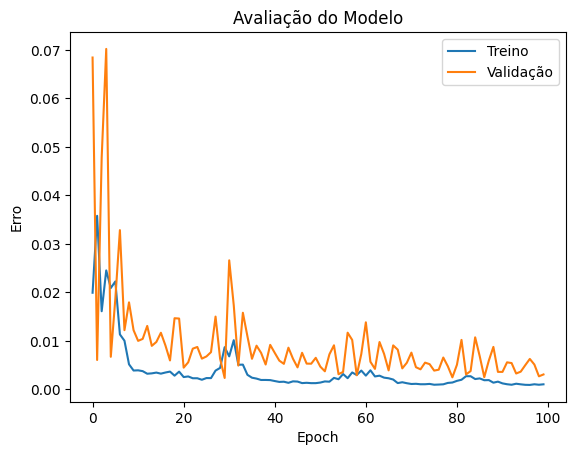

In [39]:
# Plot
plt.plot(modelo_gru_history.history['loss'])
plt.plot(modelo_gru_history.history['val_loss'])
plt.title('Avaliação do Modelo')
plt.ylabel('Erro')
plt.xlabel('Epoch')
plt.legend(['Treino', 'Validação'], loc = 'upper right')
plt.show()

In [40]:
y_pred = modelo_gru.predict(X_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


In [41]:
y_pred

array([[1.2603637],
       [1.2065216],
       [1.213599 ],
       [1.2698529],
       [1.2339374],
       [1.2171383],
       [1.234803 ],
       [1.2860065],
       [1.2876147],
       [1.3287091],
       [1.3063538],
       [1.2936437],
       [1.2910167],
       [1.2840892],
       [1.2887776],
       [1.3112212],
       [1.3494688],
       [1.3404453],
       [1.3621553],
       [1.3707327],
       [1.3670787],
       [1.337503 ],
       [1.3364873],
       [1.2510977],
       [1.2547748],
       [1.2078031],
       [1.1770366],
       [1.1907759],
       [1.2275844],
       [1.2517719],
       [1.1895053],
       [1.1314256],
       [1.1511712],
       [1.1885022],
       [1.1719066],
       [1.1552898],
       [1.1117487],
       [1.1642692],
       [1.2074919],
       [1.2478116],
       [1.2103673],
       [1.1828344],
       [1.1849198],
       [1.2631607],
       [1.2923884],
       [1.3043547],
       [1.2971311],
       [1.2969735],
       [1.299095 ],
       [1.3504729],


In [42]:
# Invertemos a escala para visualizar o valor real e a previsão
y_train_inv = scaler_target.inverse_transform(y_train.reshape(1, -1))
y_test_inv = scaler_target.inverse_transform(y_test.reshape(1, -1))
y_pred_inv = scaler_target.inverse_transform(y_pred.reshape(1,-1))

In [43]:
# Ajusta o shape
y_train_inv = y_train_inv.flatten()
y_test_inv = y_test_inv.flatten()
y_pred_inv = y_pred_inv.flatten()

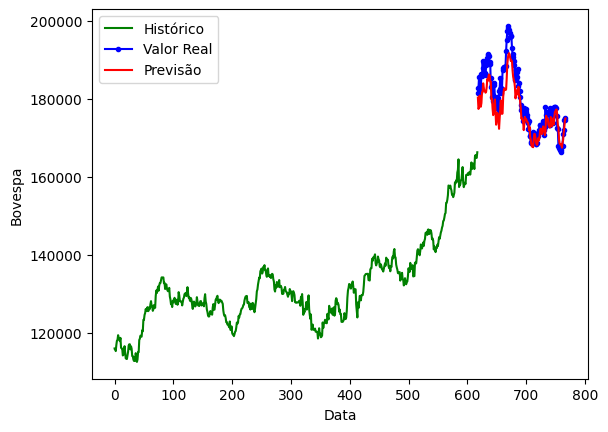

In [44]:
# Plot
plt.plot(np.arange(0, len(y_train)), 
         y_train_inv, 
         color = 'green', 
         label = "Histórico")

plt.plot(np.arange(len(y_train), 
                   len(y_train) + len(y_test)), 
         y_test_inv, 
         color = 'blue', 
         marker = '.', 
         label = "Valor Real")

plt.plot(np.arange(len(y_train), 
                   len(y_train) + len(y_test)), 
         y_pred_inv, 
         color = 'red', 
         label = "Previsão")

plt.ylabel('Bovespa')
plt.xlabel('Data')
plt.legend()
plt.show();

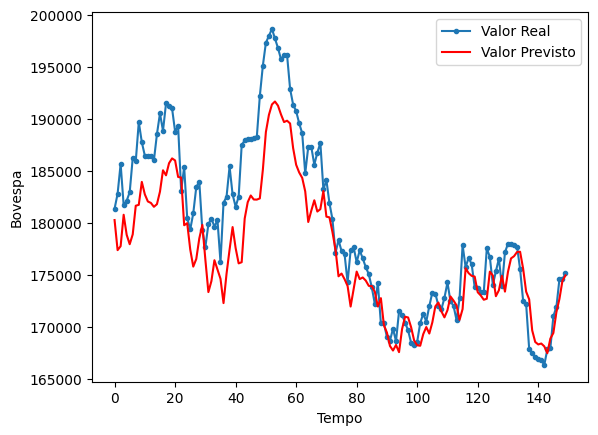

In [45]:
# Plot apenas do valor real x valor previsto
plt.plot(y_test_inv, marker = '.', label = "Valor Real")
plt.plot(y_pred_inv, color = 'red', label = "Valor Previsto")
plt.ylabel('Bovespa')
plt.xlabel('Tempo')
plt.legend()
plt.show();

In [46]:
# Mean Directional Accuracy
def mda(actual: np.ndarray, predicted: np.ndarray):
    return np.mean((np.sign(actual[1:] - actual[:-1]) == np.sign(predicted[1:] - predicted[:-1])).astype(int))

In [47]:
# Imprime as métricas

MDA_gru = mda(y_test_inv, y_pred_inv)
print('MDA:', MDA_gru)

MAE_gru = mean_absolute_error(y_test_inv, y_pred_inv)
print('MAE:', MAE_gru)

MSE_gru = mean_squared_error(y_test_inv, y_pred_inv)
print('MSE:', MSE_gru)

RMSE_gru = root_mean_squared_error(y_test_inv, y_pred_inv)
print('RMSE:', RMSE_gru)

EVS_gru = explained_variance_score(y_test_inv, y_pred_inv)
print('EVS Score:', EVS_gru)

MDA: 0.5369127516778524
MAE: 3301.1354166666665
MSE: 17609974.72135742
RMSE: 4196.424039745914
EVS Score: 0.855297029975008


In [48]:
# Salva o modelo
def save_model(model):
    json_model = model.to_json()
    open('modelos/modelo_gru.json', 'w').write(json_model)
    
    # Agora sim, adicionando o ".weights" na string do arquivo!
    model.save_weights('modelos/modelo_gru.weights.h5', overwrite=True) 

In [49]:
save_model(modelo_gru)

In [50]:
import joblib
import os
from sklearn.preprocessing import MinMaxScaler

# Cria a pasta 'modelos' caso ela ainda não exista
if not os.path.exists('modelos'):
    os.makedirs('modelos')

# =====================================================================
# 1. CRIANDO E TREINANDO OS SCALERS (Para garantir que existem na memória)
# =====================================================================
colunas_features = df.columns
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# O .fit() é o que faz o scaler aprender os mínimos e máximos da sua base 'df'
scaler_X.fit(df[colunas_features])
scaler_y.fit(df['Bovespa'].values.reshape(-1, 1))

# =====================================================================
# 2. SALVANDO OS SCALERS NO SEU COMPUTADOR
# =====================================================================
joblib.dump(scaler_X, 'modelos/scaler_X.pkl')
joblib.dump(scaler_y, 'modelos/scaler_y.pkl')

print("✅ Scalers criados, treinados e salvos com sucesso na pasta 'modelos'!")

✅ Scalers criados, treinados e salvos com sucesso na pasta 'modelos'!
